# MDN Baseline: Coupled Double-Well System

Investigates whether a **Mixture Density Network (MDN) ensemble** can learn the
conditional output distribution of the coupled double-well simulator

$$p(y \mid x)$$

where $x = [q_0,\, \sigma,\, \kappa]$ parameterises the initial conditions and
physics, and $y = q(T)$ are the final particle positions after overdamped
Langevin integration.

Unlike the synthetic multimodal-conditional benchmark, there is **no closed-form
log-likelihood** here — the simulator is a black box.  We evaluate models purely
via the **ensemble NLL** and visual comparison of predicted vs true samples.

In [72]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # replace with desired GPU
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

%matplotlib inline
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
import jax
import jax.numpy as jnp
from jax import random

import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [74]:
%autoreload 2

_repo_root   = str(Path("../..").resolve())
_example_dir = str(Path(".").resolve())
for _p in [_repo_root, _example_dir]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import optax
from jaxmix.archs import MLP, MDN, Ensemble
from jaxmix.trainers import MDNTrainer, MSETrainer, mdn_loss_func
from jaxmix.data_loaders import BatchedDataset

from coupled_double_well import generate_dataset, make_oracle
from active_learning_utils import create_shared_double_well_data
from examples.common_active_learning import evaluate_ensemble_nll

In [75]:
key = random.PRNGKey(42)
model_init_key = random.PRNGKey(67)

## Physics Setup

The coupled double-well system evolves $P$ particles in 1-D potentials
$V(q) = -\tfrac{a}{2}q^2 + \tfrac{a}{4}q^4$ with nearest-neighbour coupling
$\kappa$ and noise intensity $\sigma$.  The ratio $\sigma^2/a$ controls a
**unimodal → bimodal phase transition** in $p(y|x)$.

In [76]:
# ----- Simulator hyperparameters (same as active_learning.ipynb) -----
P           = 5       # number of particles
T           = 5.0     # integration time
DT          = 0.005   # time step
N_SNAPSHOTS = 4       # snapshots along trajectory (matches AL experiment)
SIGMA_RANGE = (0.3, 2.0)
KAPPA_RANGE = (0.0, 3.0)

OUT_DIM = N_SNAPSHOTS * P   # 4 snapshots * 5 particles = 20
IN_DIM  = P + 2             # [q0, sigma, kappa]

print(f"Particles        : {P}")
print(f"Snapshots        : {N_SNAPSHOTS}")
print(f"Input dimension  : {IN_DIM}  (q0 + sigma + kappa)")
print(f"Output dimension : {OUT_DIM}  ({N_SNAPSHOTS} snapshots * {P} particles)")

Particles        : 5
Snapshots        : 4
Input dimension  : 7  (q0 + sigma + kappa)
Output dimension : 20  (4 snapshots * 5 particles)


## Verify Phase Transition

Before training any model, let's visualise the physics.  At low $\sigma$ the
particle stays trapped near one well; at high $\sigma$ it equilibrates across
both wells, producing a bimodal output distribution.

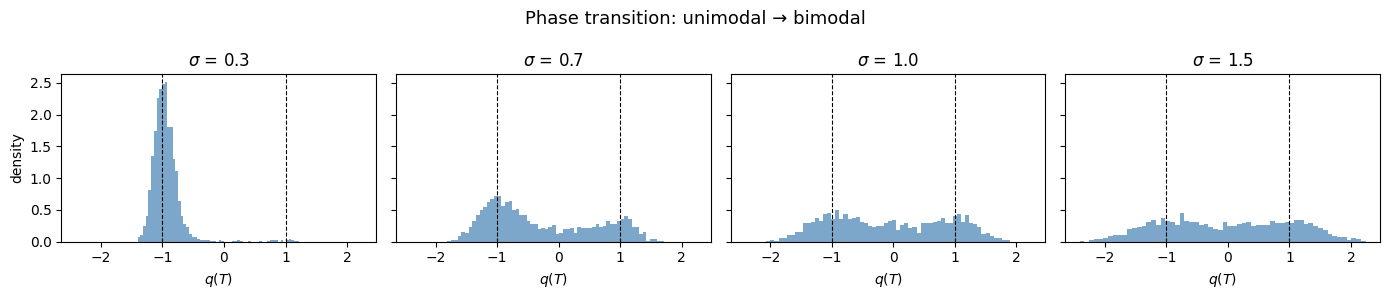

In [77]:
from coupled_double_well import verify_phase_diagram
verify_phase_diagram()

## Generate Dataset

We use `create_shared_double_well_data` (same interface as the active learning
notebook) but with a larger pool to give the baseline the best possible
training loss.

In [78]:
data = create_shared_double_well_data(
    seed=0,
    candidate_sample_count=200_000,
    test_sample_count=5_000,
    initial_sample_count=100,
    P=P, T=T, dt=DT,
    n_snapshots=N_SNAPSHOTS,
    sigma_range=SIGMA_RANGE,
    kappa_range=KAPPA_RANGE,
)

# Use the full pool + initial labelled set as training data for the baseline
train_inputs  = jnp.concatenate([data["initial_labeled_inputs"],
                                 data["remaining_pool_inputs"]], axis=0)
train_outputs = jnp.concatenate([data["initial_labeled_targets"],
                                 data["remaining_pool_targets"]], axis=0)
train_weights = jnp.ones((train_inputs.shape[0], 1))
train_data    = (train_inputs, train_outputs, train_weights)

test_inputs, test_outputs = data["test_data"]
test_weights = jnp.ones((test_inputs.shape[0], 1))
test_data    = (test_inputs, test_outputs, test_weights)

print(f"Train : {train_inputs.shape}  ->  {train_outputs.shape}")
print(f"Test  : {test_inputs.shape}  ->  {test_outputs.shape}")
print(f"Output mean : {float(train_outputs.mean()):.5f}")
print(f"Output std  : {float(train_outputs.std()):.3f}")

Generating 200000 pool samples...
Generating 5000 test samples...
Train : (200000, 7)  ->  (200000, 20)
Test  : (5000, 7)  ->  (5000, 20)
Output mean : 0.00064
Output std  : 0.858


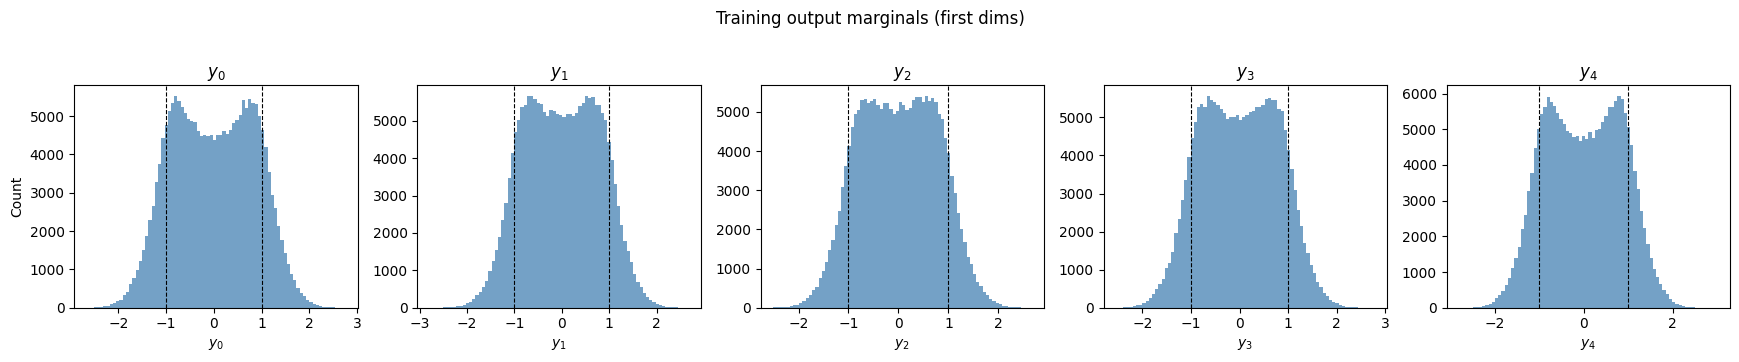

In [79]:
# Output marginals — should show bimodal structure around +/- 1
n_dims = min(5, OUT_DIM)
fig, axes = plt.subplots(1, n_dims, figsize=(3.5 * n_dims, 3.5))
if n_dims == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.hist(np.array(train_outputs[:, i]), bins=80, edgecolor="none",
            alpha=0.75, color="steelblue")
    ax.axvline(-1, color="k", ls="--", lw=0.8)
    ax.axvline(+1, color="k", ls="--", lw=0.8)
    ax.set_title(f"$y_{{{i}}}$")
    ax.set_xlabel(f"$y_{{{i}}}$")

axes[0].set_ylabel("Count")
plt.suptitle("Training output marginals (first dims)", y=1.02)
plt.tight_layout()
plt.show()

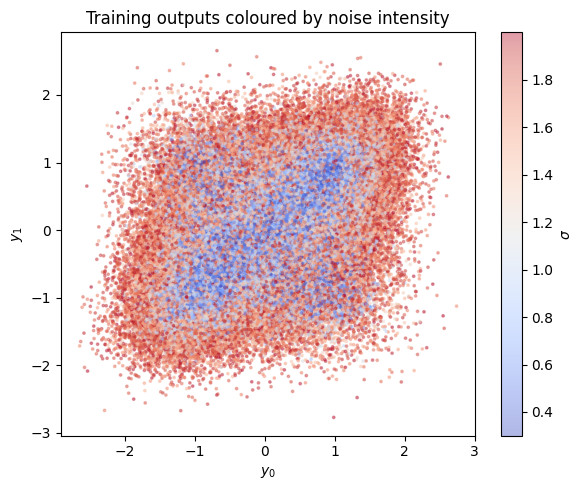

In [80]:
# Scatter of first two output dims coloured by sigma
sigma_vals = train_inputs[:, P]

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(np.array(train_outputs[:, 0]),
                np.array(train_outputs[:, 1]),
                c=np.array(sigma_vals), s=3, alpha=0.4, cmap="coolwarm")
plt.colorbar(sc, ax=ax, label=r"$\sigma$")
ax.set_xlabel("$y_0$")
ax.set_ylabel("$y_1$")
ax.set_title("Training outputs coloured by noise intensity")
plt.tight_layout()
plt.show()

## Defining Model Architectures

In [81]:
ensemble_size = 8
num_mixtures  = 8
hidden = 128
depth = 3

# MSE Baseline
mse_base_arch = MLP(features=[hidden] * depth + [OUT_DIM])
mse_arch = Ensemble(mse_base_arch, ensemble_size)

# MDN
mdn_base_arch = MLP(features=[hidden] * depth)
mdn_backbone_arch = Ensemble(mdn_base_arch, ensemble_size)
MDN_arch = MDN(
    num_mixtures=num_mixtures,
    num_output_dims=OUT_DIM,
    backbone=mdn_backbone_arch,
    ensemble_size=ensemble_size,
)

# Shared LR schedule + optimiser
num_linear_steps = 3_000
peak_lr          = 5e-4
lr = optax.join_schedules(
    schedules=[
        optax.linear_schedule(
            init_value=0.0, end_value=peak_lr, transition_steps=num_linear_steps,
        ),
        optax.exponential_decay(
            init_value=peak_lr, transition_steps=5_000, decay_rate=0.9,
        ),
    ],
    boundaries=[num_linear_steps],
)
optimizer = optax.chain(
    optax.adaptive_grad_clip(0.1),
    optax.adamw(learning_rate=lr, weight_decay=1e-5),
)

## MSE Baseline Training

The MSE model minimises $\mathbb{E}[\|y - \hat{y}(x)\|^2]$.  Because the
conditional mean sits between the two wells, the MSE predictor will converge to
a point near the unstable equilibrium — it cannot capture the bimodal structure.

In [82]:
init_batch = (train_inputs, train_outputs, train_weights)
key, subkey = random.split(model_init_key)
mse_model = MSETrainer(
    mse_arch, init_batch, key=subkey, optimizer=optimizer,
    normalize_inputs=True, normalize_outputs=True,
)
print(mse_model.tabulate())


                                          Ensemble Summary                                           
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module   ┃ inputs              ┃ outputs              ┃ params                     ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│              │ Ensemble │ float32[200000,7]   │ float32[8,200000,20] │                            │
├──────────────┼──────────┼─────────────────────┼──────────────────────┼────────────────────────────┤
│ arch         │ MLP      │ float32[200000,7]   │ float32[200000,20]   │                            │
├──────────────┼──────────┼─────────────────────┼──────────────────────┼────────────────────────────┤
│ arch/Dense_0 │ Dense    │ float32[200000,7]   │ float32[200000,128]  │ bias: float32[8,128]       │
│              │          │                     │                      │ kernel: 

In [83]:
key, loader_key = random.split(key)
train_loader = BatchedDataset(train_data, loader_key, batch_size=256)
mse_model.train(train_loader, nIter=100_000)

100%|██████████| 100000/100000 [01:29<00:00, 1111.61it/s, loss=0.8578192, grad_norm=0.0626304]  


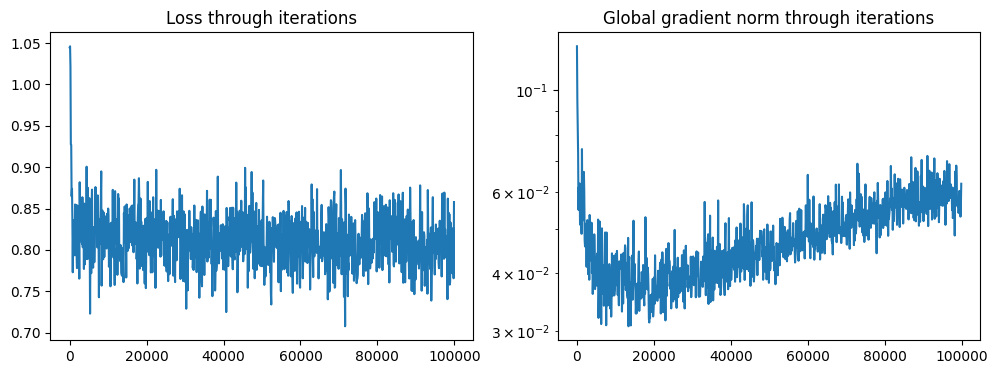

In [84]:
mse_model.plot_logs()

## MDN Training

The MDN maximises the log-likelihood under its Gaussian mixture model.
With enough mixture components it should capture the bimodal wells.

In [85]:
key, subkey = random.split(model_init_key)
mdn_model = MDNTrainer(
    MDN_arch, init_batch, key=subkey, optimizer=optimizer,
    normalize_inputs=True, normalize_outputs=True,
)
print(mdn_model.tabulate())


                                                      MDN Summary                                                       
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module       ┃ inputs                  ┃ outputs                  ┃ params                   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ MDN          │ float32[200000,7]       │ - float32[8,200000,8,1]  │                          │
│                       │              │                         │ - float32[8,200000,8,20] │                          │
│                       │              │                         │ - float32[8,200000,8,20] │                          │
├───────────────────────┼──────────────┼─────────────────────────┼──────────────────────────┼──────────────────────────┤
│ backbone              │ Ensem

In [86]:
key, loader_key = random.split(key)
train_loader = BatchedDataset(train_data, loader_key, batch_size=256)
mdn_model.train(train_loader, nIter=150_000)

100%|██████████| 150000/150000 [02:20<00:00, 1067.96it/s, loss=19.59692, grad_norm=1.4776193] 


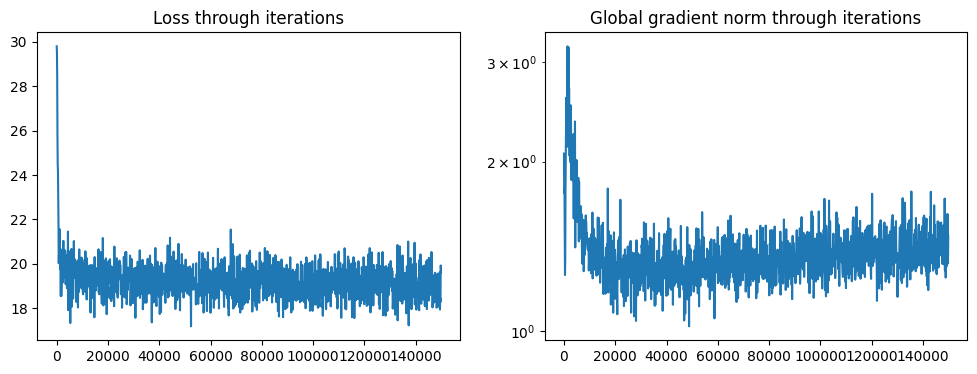

In [87]:
mdn_model.plot_logs()

## Evaluation

Without a closed-form likelihood we cannot compute the true NLL floor.
We report the **ensemble NLL** and compare MSE vs MDN visually.

In [88]:
# MDN ensemble NLL on test set
mdn_nll = evaluate_ensemble_nll(mdn_model, test_inputs, test_outputs)

# MSE test loss (mean per output dim)
mse_preds = mse_model.apply(mse_model.params, test_inputs)  # (E, N, M)
mse_mean_pred = float(mse_preds.mean(axis=0).mean())
mse_test_loss = float(((mse_preds.mean(axis=0) - test_outputs) ** 2).mean())

print(f"MDN ensemble NLL        : {mdn_nll:.4f}")
print()
print(f"MSE model mean output   : {mse_mean_pred:.5f}")
print(f"MSE test loss           : {mse_test_loss:.4f}  (approx output variance)")

MDN ensemble NLL        : 15.9010

MSE model mean output   : -0.00931
MSE test loss           : 0.6024  (approx output variance)


## Single-Gaussian (K=1) MDN Baseline

Intermediate between MSE and the full MDN: an `MDNTrainer` with `num_mixtures=1`
is a Gaussian-NLL model.  It captures the conditional **mean and variance** but
is structurally incapable of representing multimodality — a useful diagnostic for
how much of the MDN's advantage comes from modelling spread vs. modelling modes.

In [89]:
MDN_single_arch = MDN(
    num_mixtures=1,
    num_output_dims=OUT_DIM,
    backbone=mdn_backbone_arch,
    ensemble_size=ensemble_size,
)

key, subkey = random.split(model_init_key)
mdn_single_model = MDNTrainer(
    MDN_single_arch, init_batch, key=subkey, optimizer=optimizer,
    normalize_inputs=True, normalize_outputs=True,
)
print(mdn_single_model.tabulate())


                                                      MDN Summary                                                       
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module       ┃ inputs                  ┃ outputs                  ┃ params                   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ MDN          │ float32[200000,7]       │ - float32[8,200000,1,1]  │                          │
│                       │              │                         │ - float32[8,200000,1,20] │                          │
│                       │              │                         │ - float32[8,200000,1,20] │                          │
├───────────────────────┼──────────────┼─────────────────────────┼──────────────────────────┼──────────────────────────┤
│ backbone              │ Ensem

100%|██████████| 150000/150000 [02:53<00:00, 863.18it/s, loss=24.785238, grad_norm=4.4804273] 


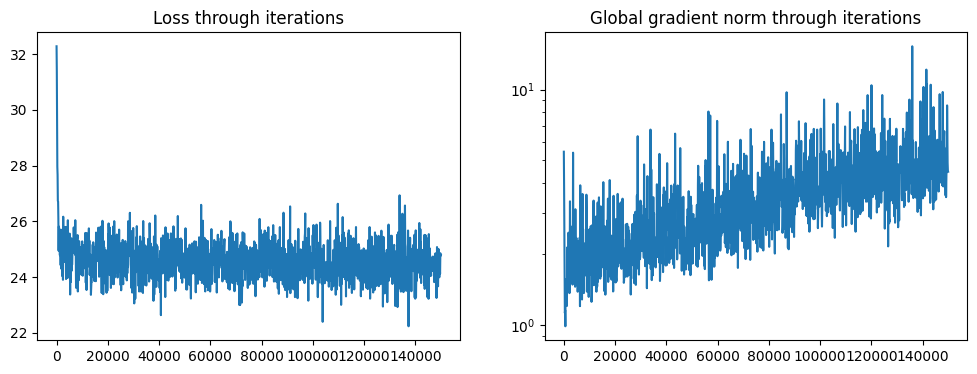

In [90]:
key, loader_key = random.split(key)
train_loader = BatchedDataset(train_data, loader_key, batch_size=256)
mdn_single_model.train(train_loader, nIter=150000)
mdn_single_model.plot_logs()

In [91]:
mdn_single_nll = evaluate_ensemble_nll(mdn_single_model, test_inputs, test_outputs)

print(f"MDN (K={num_mixtures}) ensemble NLL   : {mdn_nll:.4f}")
print(f"MDN (K=1) ensemble NLL        : {mdn_single_nll:.4f}")

MDN (K=8) ensemble NLL   : 15.9010
MDN (K=1) ensemble NLL        : 21.4079


## Visual Comparison

### 1. Predicted samples vs. true samples  ($y_0$ - $y_1$ scatter)

The MDN samples one $y$ per test input from the mixture.  Bimodal clustering
around $\pm 1$ in each axis indicates successful recovery of the well structure.

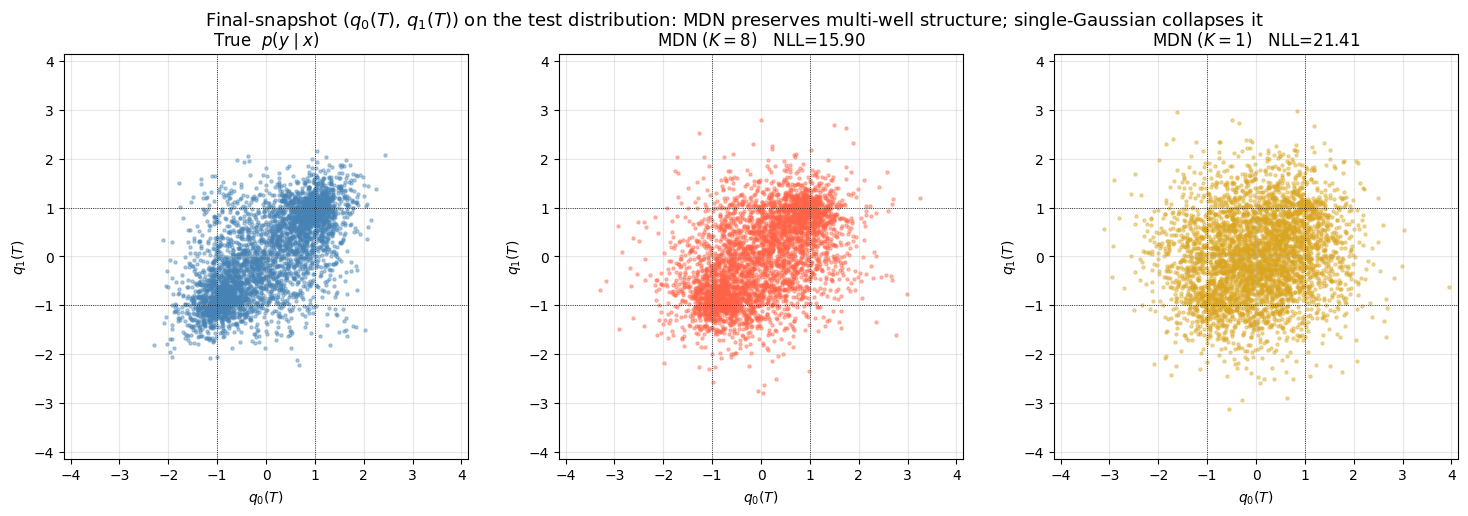

In [92]:
import os

# Use the SAME evaluation distribution as the active learning notebook:
# q0 ~ U[-1.5, 1.5], sigma ~ U[0.3, 2.0], kappa ~ U[0.0, 3.0].  The test
# inputs are already drawn from this joint, so we reuse them directly.
n_show = min(4000, test_inputs.shape[0])
x_cond = test_inputs[:n_show]
y_true = np.asarray(test_outputs[:n_show])

# MDN (K=num_mixtures) samples, net 0
pred = mdn_model.apply(mdn_model.params, x_cond)
lw, mu, var = pred
mdn_samp = mdn_model.sample_from_mixture(random.PRNGKey(0), lw, mu, var)
y_mdn = np.asarray(mdn_samp[0]).squeeze(1)      # (N, 20)

# MDN (K=1) samples, net 0
pred_s = mdn_single_model.apply(mdn_single_model.params, x_cond)
lw_s, mu_s, var_s = pred_s
mdn_s_samp = mdn_single_model.sample_from_mixture(random.PRNGKey(1), lw_s, mu_s, var_s)
y_single = np.asarray(mdn_s_samp[0]).squeeze(1)  # (N, 20)

# Indices of particles 0 and 1 at the final snapshot (t=T).
# Layout is row-major [snap0_p0..p4, snap1_p0..p4, snap2_p0..p4, snap3_p0..p4].
i0 = (N_SNAPSHOTS - 1) * P + 0
i1 = (N_SNAPSHOTS - 1) * P + 1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# True
ax = axes[0]
ax.scatter(y_true[:, i0], y_true[:, i1], s=5, alpha=0.4, c="steelblue")
for c in (-1, 1):
    ax.axvline(c, color="k", ls=":", lw=0.6)
    ax.axhline(c, color="k", ls=":", lw=0.6)
ax.set_xlabel(r"$q_0(T)$"); ax.set_ylabel(r"$q_1(T)$")
ax.set_title(r"True  $p(y \mid x)$")
ax.grid(True, alpha=0.3)

# MDN K>1
ax = axes[1]
ax.scatter(y_mdn[:, i0], y_mdn[:, i1], s=5, alpha=0.4, c="tomato")
for c in (-1, 1):
    ax.axvline(c, color="k", ls=":", lw=0.6)
    ax.axhline(c, color="k", ls=":", lw=0.6)
ax.set_xlabel(r"$q_0(T)$"); ax.set_ylabel(r"$q_1(T)$")
ax.set_title(fr"MDN ($K={num_mixtures}$)   NLL={mdn_nll:.2f}")
ax.grid(True, alpha=0.3)

# MDN K=1
ax = axes[2]
ax.scatter(y_single[:, i0], y_single[:, i1], s=5, alpha=0.4, c="goldenrod")
for c in (-1, 1):
    ax.axvline(c, color="k", ls=":", lw=0.6)
    ax.axhline(c, color="k", ls=":", lw=0.6)
ax.set_xlabel(r"$q_0(T)$"); ax.set_ylabel(r"$q_1(T)$")
ax.set_title(fr"MDN ($K=1$)   NLL={mdn_single_nll:.2f}")
ax.grid(True, alpha=0.3)

# Shared axis limits for an honest visual comparison
all_vals = np.concatenate(
    [y_true[:, [i0, i1]], y_mdn[:, [i0, i1]], y_single[:, [i0, i1]]]
)
lim = float(np.max(np.abs(all_vals))) * 1.05
for ax in axes:
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

plt.suptitle(
    r"Final-snapshot $(q_0(T),\, q_1(T))$ on the test distribution: "
    r"MDN preserves multi-well structure; single-Gaussian collapses it",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### 2. Output marginals: true vs MDN samples

Overlaid histograms for the first output dimensions.  The MDN should recover
the bimodal peaks near $\pm 1$.

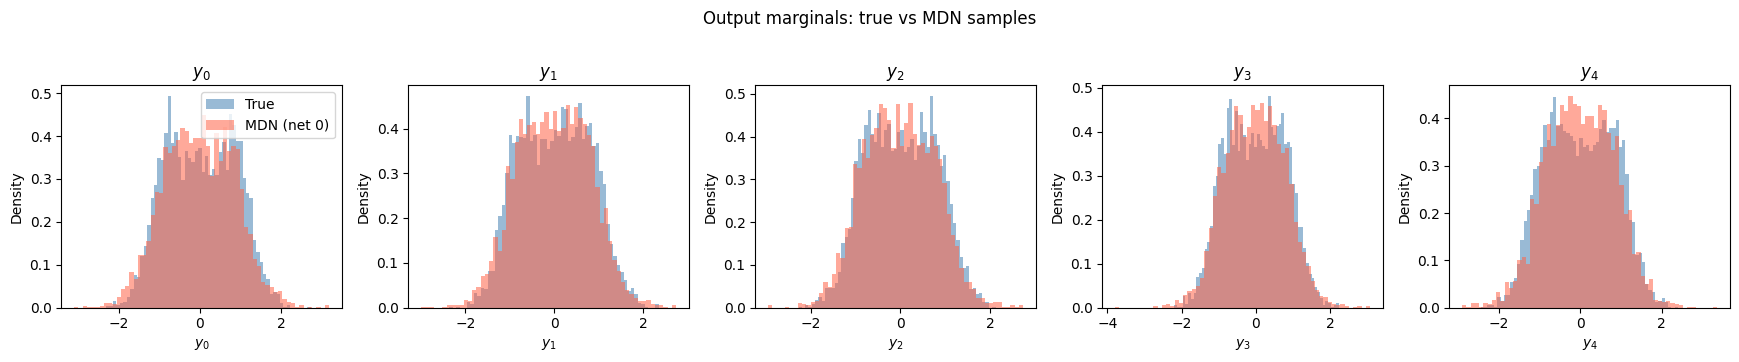

In [93]:
if "y_mdn" not in globals():
    logit_weights, means, variances = mdn_model.apply(mdn_model.params, test_inputs)
    mdn_samp = mdn_model.sample_from_mixture(
        random.PRNGKey(0), logit_weights, means, variances,
    )
    y_mdn = np.asarray(mdn_samp[0]).squeeze(1)

n_dims = min(5, OUT_DIM)
fig, axes = plt.subplots(1, n_dims, figsize=(3.5 * n_dims, 3.5))
if n_dims == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.hist(np.asarray(test_outputs[:, i]), bins=60,
            alpha=0.55, color="steelblue", label="True", density=True)
    ax.hist(y_mdn[:, i], bins=60,
            alpha=0.55, color="tomato", label="MDN (net 0)", density=True)
    ax.set_title(f"$y_{{{i}}}$")
    ax.set_xlabel(f"$y_{{{i}}}$")
    ax.set_ylabel("Density")
    if i == 0:
        ax.legend()

plt.suptitle("Output marginals: true vs MDN samples", y=1.02)
plt.tight_layout()
plt.show()

### 3. Ensemble spread  (all nets on same test points)

Each ensemble member independently samples from its own mixture.  The spread
across nets reflects epistemic uncertainty — high spread signals regions where
the model is less confident about the conditional distribution.

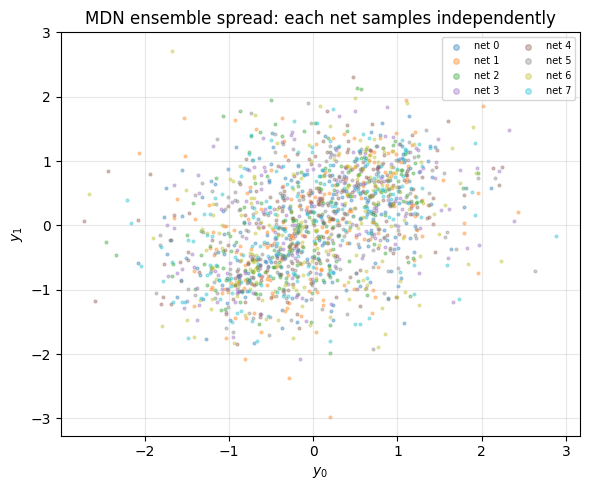

Per-net MDN NLL:
  Net 0: 16.3071
  Net 1: 16.2632
  Net 2: 16.2834
  Net 3: 16.3021
  Net 4: 16.2840
  Net 5: 16.2890
  Net 6: 16.2913
  Net 7: 16.2956
  MDN ensemble (avg over nets): 15.9010


In [94]:
logit_weights, means, variances = mdn_model.apply(mdn_model.params, test_inputs)
mdn_samp = mdn_model.sample_from_mixture(
    random.PRNGKey(0), logit_weights, means, variances,
)

# One sample per network for the same test inputs
all_net_samples = np.asarray(mdn_samp).squeeze(2)   # (E, N, M)

colors_nets = plt.cm.tab10(np.linspace(0, 1, ensemble_size))
n_show_ens = min(200, test_inputs.shape[0])

fig, ax = plt.subplots(figsize=(6, 5))
for e_idx in range(ensemble_size):
    ax.scatter(
        all_net_samples[e_idx, :n_show_ens, 0],
        all_net_samples[e_idx, :n_show_ens, 1],
        s=4, alpha=0.35, color=colors_nets[e_idx],
        label=f"net {e_idx}",
    )
ax.set_xlabel("$y_0$"); ax.set_ylabel("$y_1$")
ax.set_title("MDN ensemble spread: each net samples independently")
ax.legend(markerscale=2, fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Per-net NLL
print("Per-net MDN NLL:")
per_net_nll = mdn_loss_func(logit_weights, means, variances, test_outputs)  # (E, N, 1)
for e_idx in range(ensemble_size):
    nll_e = float(per_net_nll[e_idx].mean())
    print(f"  Net {e_idx}: {nll_e:.4f}")
print(f"  MDN ensemble (avg over nets): {mdn_nll:.4f}")

### 4. Conditional samples at fixed sigma values

To verify the MDN captures the phase transition, we condition on specific
$\sigma$ values and compare predicted vs true marginals for particle 0.

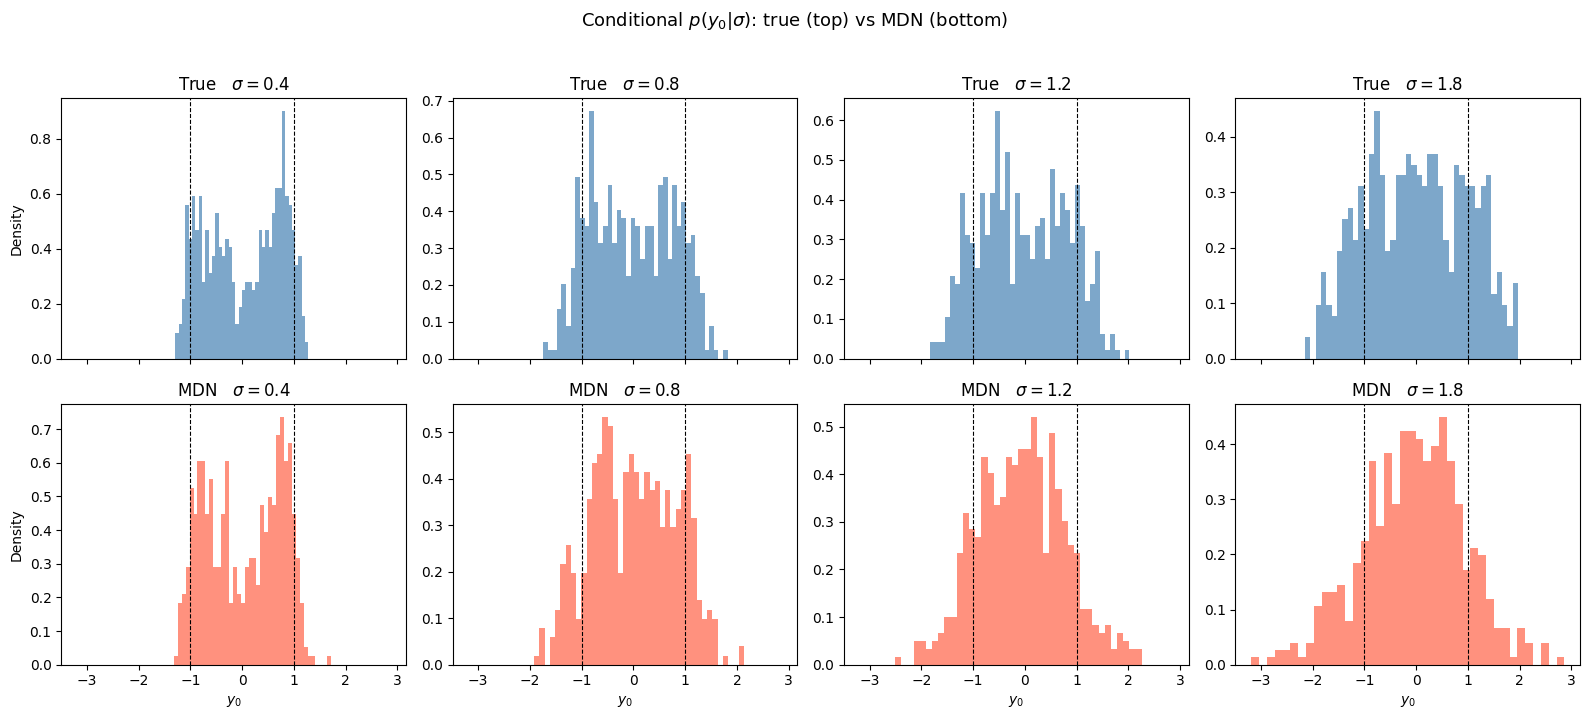

In [95]:
oracle = make_oracle(P=P, T=T, dt=DT, n_snapshots=N_SNAPSHOTS)

sigma_probes = [0.4, 0.8, 1.2, 1.8]
n_cond = 500

fig, axes = plt.subplots(2, len(sigma_probes),
                         figsize=(4 * len(sigma_probes), 7),
                         sharex=True)

for j, sigma_val in enumerate(sigma_probes):
    # Build a batch of inputs with fixed sigma, random q0 and kappa
    cond_key = random.PRNGKey(100 + j)
    k1, k2, k3 = random.split(cond_key, 3)
    q0_cond = random.uniform(k1, (n_cond, P), minval=-1.5, maxval=1.5)
    kappa_cond = random.uniform(k2, (n_cond,), minval=KAPPA_RANGE[0],
                                maxval=KAPPA_RANGE[1])
    sigma_cond = jnp.full(n_cond, sigma_val)
    x_cond = jnp.concatenate([q0_cond, sigma_cond[:, None],
                              kappa_cond[:, None]], axis=-1)

    # True samples from oracle
    y_true_cond = oracle(x_cond, k3)

    # MDN samples
    pred_cond = mdn_model.apply(mdn_model.params, x_cond)
    lw_c, mu_c, var_c = pred_cond
    mdn_cond = mdn_model.sample_from_mixture(
        random.PRNGKey(200 + j), lw_c, mu_c, var_c,
    )
    y_mdn_cond = np.asarray(mdn_cond[0]).squeeze(1)

    # True
    ax = axes[0, j]
    ax.hist(np.asarray(y_true_cond[:, 0]), bins=40, density=True,
            alpha=0.7, color="steelblue")
    ax.axvline(-1, color="k", ls="--", lw=0.8)
    ax.axvline(+1, color="k", ls="--", lw=0.8)
    ax.set_title(f"True   $\\sigma={sigma_val}$")
    if j == 0:
        ax.set_ylabel("Density")

    # MDN
    ax = axes[1, j]
    ax.hist(y_mdn_cond[:, 0], bins=40, density=True,
            alpha=0.7, color="tomato")
    ax.axvline(-1, color="k", ls="--", lw=0.8)
    ax.axvline(+1, color="k", ls="--", lw=0.8)
    ax.set_title(f"MDN   $\\sigma={sigma_val}$")
    ax.set_xlabel("$y_0$")
    if j == 0:
        ax.set_ylabel("Density")

plt.suptitle("Conditional $p(y_0 | \\sigma)$: true (top) vs MDN (bottom)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()